# Architecture comparison on 8-ch walking-frame v2

Six 1-D CNN variants trained on the same input
(`compute_walking_frame_features_v2`) and the same MotionSense
subject split. Each variant is evaluated on (i) the MotionSense
held-out subjects 19-23, (ii) all twelve labelled Android sessions
under `data/in_the_wild/labels.csv`.

| ID | Architecture | 
|----|--------------|
| A | Baseline (3× Conv + 2× MaxPool + GAP + Dense) |
| B | Dilated 1/2/4 (no MaxPool, kept temporal resolution) |
| C | B + ECP final pooling instead of GAP |
| D | B + L2 + SpatialDropout1D + label smoothing |
| E | B + ECP + regularisation |
| F | B + CMV between dilated blocks |

Acceptance criteria:
1. Best variant > 0.9519 macro-F1 (the SVC-RBF reference)
2. `ups` F1 ≥ 0.92 per class
3. Train/val gap visibly smaller than the baseline
4. Android session-acc ≥ 0.85

References for the architectural choices:

> Yu, F. & Koltun, V. (2016). Multi-scale context aggregation by dilated convolutions. *ICLR 2016*. https://arxiv.org/abs/1511.07122

> Wang, Z., Yan, W., & Oates, T. (2017). Time series classification from scratch with deep neural networks: A strong baseline. *IJCNN 2017*. https://doi.org/10.1109/IJCNN.2017.7966039

> Ameen, B. A. H., & Aminifar, S. A. (2026). Robust Activity Recognition via Redundancy-Aware CNNs and Novel Pooling for Noisy Mobile Sensor Data. *Sensors*, 26(2), 710. https://doi.org/10.3390/s26020710 -- inspiration for the `ECPPooling`/`CMVPooling` layers used in variants C/E/F below; the formulas implemented here are project adaptations, not identical to the paper's (see `utils/custom_layers.py` docstring for the exact difference). An earlier version of this citation misattributed the same PMC ID to different authors and a different title -- corrected 2026-07-22.

> Srivastava, N. et al. (2014). Dropout: A simple way to prevent neural networks from overfitting. *JMLR*, 15.

> Müller, R., Kornblith, S., & Hinton, G. (2019). When does label smoothing help? *NeurIPS 2019*. https://arxiv.org/abs/1906.02629


In [ ]:
import os, sys, json, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf, keras
from keras import layers, callbacks, regularizers, losses
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore')
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)

_ROOT = Path('..').resolve(); sys.path.insert(0, str(_ROOT))
from utils.orientation_invariant_features import (compute_walking_frame_features_v2, WALKING_FRAME_V2_COLS)
from utils.custom_layers import ECPPooling, CMVPooling
print('feature columns:', WALKING_FRAME_V2_COLS)


feature columns: ['acc_mag', 'gyro_mag', 'a_v', 'a_h', 'jerk_v', 'a_f_mag', 'a_s_mag', 'gyro_v']


## Section 1 — Data preparation (same pipeline as notebook 11)

In [2]:
ACT_LABELS = ['dws','ups','wlk','jog','std','sit']
TRIAL_CODES = {
    'dws': [1,2,11], 'ups': [3,4,12], 'wlk': [7,8,15],
    'jog': [9,16],   'std': [6,14],   'sit': [5,13],
}


def get_ds_infos(): return pd.read_csv('../../data/data_subjects_info.csv')
def set_data_types(types):
    return [[t+'.x',t+'.y',t+'.z'] if t!='attitude' else ['attitude.roll','attitude.pitch','attitude.yaw'] for t in types]


def create_time_series(dt_list, act_labels, trial_codes):
    n_cols = len(dt_list)*3
    dataset = np.zeros((0, n_cols+7))
    ds_list = get_ds_infos()
    for sub_id in ds_list['code']:
        for act_id, act in enumerate(act_labels):
            for trial in trial_codes[act]:
                f = f'../../data/A_DeviceMotion_data/{act}_{trial}/sub_{int(sub_id)}.csv'
                raw = pd.read_csv(f).drop(['Unnamed: 0'], axis=1)
                vals = np.zeros((len(raw), n_cols))
                for x, axes in enumerate(dt_list):
                    vals[:, x*3:(x+1)*3] = raw[axes].values
                lbls = np.array([[act_id, sub_id-1,
                                  ds_list['weight'][sub_id-1],
                                  ds_list['height'][sub_id-1],
                                  ds_list['age'][sub_id-1],
                                  ds_list['gender'][sub_id-1], trial]] * len(raw))
                dataset = np.append(dataset, np.concatenate((vals, lbls), axis=1), axis=0)
    cols = [c for axes in dt_list for c in axes] + ['act','id','weight','height','age','gender','trial']
    return pd.DataFrame(data=dataset, columns=cols)


def sliding_windows(data, feature_cols, w=128, s=64):
    X, y, g = [], [], []
    for (sid, act, _), b in data.groupby(['id','act','trial'], sort=False):
        v = b[feature_cols].to_numpy()
        for st in range(0, len(v)-w+1, s):
            X.append(v[st:st+w]); y.append(act); g.append(sid)
    return np.array(X), np.array(y), np.array(g)


dt_list = set_data_types(['attitude','gravity','rotationRate','userAcceleration'])
dataset = create_time_series(dt_list, ACT_LABELS, TRIAL_CODES)
for col in ('act','id','trial'): dataset[col] = dataset[col].astype(int)
features_df = compute_walking_frame_features_v2(dataset, fs_hz=50.0, smooth_seconds=5.0)
print('features_df shape:', features_df.shape)


features_df shape: (1412865, 15)


In [3]:
train_ids = list(range(0, 15)); val_ids = list(range(15, 19)); test_ids = list(range(19, 24))
X_train, y_train, g_train = sliding_windows(features_df[features_df['id'].isin(train_ids)], WALKING_FRAME_V2_COLS)
X_val,   y_val,   g_val   = sliding_windows(features_df[features_df['id'].isin(val_ids)],   WALKING_FRAME_V2_COLS)
X_test,  y_test,  g_test  = sliding_windows(features_df[features_df['id'].isin(test_ids)],  WALKING_FRAME_V2_COLS)
y_train, y_val, y_test = y_train.astype(int), y_val.astype(int), y_test.astype(int)
N_CHAN = len(WALKING_FRAME_V2_COLS)


def normalize_dyn(X, eps=1e-8):
    out = X.copy().astype(np.float32)
    return (out - out.mean(axis=1, keepdims=True)) / (out.std(axis=1, keepdims=True) + eps)


X_train_n = normalize_dyn(X_train); X_val_n = normalize_dyn(X_val); X_test_n = normalize_dyn(X_test)
cw = compute_class_weight('balanced', classes=np.arange(6), y=y_train)
CLASS_WEIGHT = {int(i): float(w) for i, w in enumerate(cw)}
print(f'train {X_train_n.shape}, val {X_val_n.shape}, test {X_test_n.shape}')


train (13282, 128, 8), val (3905, 128, 8), test (4352, 128, 8)


## Section 2 — Six architecture builders

In [4]:
def build_A_baseline(input_shape=(128, N_CHAN), n_classes=6):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.3)(x)
    return keras.Model(inp, layers.Dense(n_classes, activation='softmax')(x), name='A_baseline')


def build_B_dilated(input_shape=(128, N_CHAN), n_classes=6):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64,  5, dilation_rate=1, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, dilation_rate=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, dilation_rate=4, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.3)(x)
    return keras.Model(inp, layers.Dense(n_classes, activation='softmax')(x), name='B_dilated')


def build_C_dilated_ecp(input_shape=(128, N_CHAN), n_classes=6):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64,  5, dilation_rate=1, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, dilation_rate=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, dilation_rate=4, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    # ECP pooling over the whole window, then global mean for permutation invariance.
    x = ECPPooling(pool_size=4)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.3)(x)
    return keras.Model(inp, layers.Dense(n_classes, activation='softmax')(x), name='C_dilated_ecp')


def build_D_dilated_regularised(input_shape=(128, N_CHAN), n_classes=6):
    reg = regularizers.l2(1e-4)
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64,  5, dilation_rate=1, padding='same', activation='relu',
                      kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Conv1D(128, 5, dilation_rate=2, padding='same', activation='relu',
                      kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Conv1D(128, 3, dilation_rate=4, padding='same', activation='relu',
                      kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(0.3)(x)
    return keras.Model(inp, layers.Dense(n_classes, activation='softmax')(x), name='D_dilated_reg')


def build_E_dilated_ecp_regularised(input_shape=(128, N_CHAN), n_classes=6):
    reg = regularizers.l2(1e-4)
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64,  5, dilation_rate=1, padding='same', activation='relu',
                      kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Conv1D(128, 5, dilation_rate=2, padding='same', activation='relu',
                      kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Conv1D(128, 3, dilation_rate=4, padding='same', activation='relu',
                      kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = ECPPooling(pool_size=4)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(0.3)(x)
    return keras.Model(inp, layers.Dense(n_classes, activation='softmax')(x), name='E_dilated_ecp_reg')


def build_F_dilated_cmv(input_shape=(128, N_CHAN), n_classes=6):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64,  5, dilation_rate=1, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = CMVPooling(pool_size=2)(x)
    x = layers.Conv1D(128, 5, dilation_rate=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = CMVPooling(pool_size=2)(x)
    x = layers.Conv1D(128, 3, dilation_rate=4, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.3)(x)
    return keras.Model(inp, layers.Dense(n_classes, activation='softmax')(x), name='F_dilated_cmv')


BUILDERS = {
    'A_baseline': build_A_baseline,
    'B_dilated': build_B_dilated,
    'C_dilated_ecp': build_C_dilated_ecp,
    'D_dilated_reg': build_D_dilated_regularised,
    'E_dilated_ecp_reg': build_E_dilated_ecp_regularised,
    'F_dilated_cmv': build_F_dilated_cmv,
}
for name, fn in BUILDERS.items():
    m = fn()
    print(f'{name:25s}  params={m.count_params():>7,}')


A_baseline                 params=111,558
B_dilated                  params=111,558
C_dilated_ecp              params=111,558


D_dilated_reg              params=111,558
E_dilated_ecp_reg          params=111,558
F_dilated_cmv              params=111,558


## Section 3 — Train each variant

In [5]:
def train_variant(name, builder, label_smoothing=0.0):
    tf.keras.backend.clear_session(); tf.random.set_seed(SEED); np.random.seed(SEED)
    model = builder()
    if label_smoothing > 0:
        # Need one-hot encoding for label smoothing in keras 3
        y_train_oh = tf.one_hot(y_train, depth=6).numpy()
        y_val_oh = tf.one_hot(y_val, depth=6).numpy()
        loss = losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
        ytr, yva = y_train_oh, y_val_oh
    else:
        loss = losses.SparseCategoricalCrossentropy()
        ytr, yva = y_train, y_val
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=loss, metrics=['accuracy'])
    cb = [callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
          callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6)]
    t0 = time.time()
    history = model.fit(X_train_n, ytr, validation_data=(X_val_n, yva),
                        epochs=50, batch_size=32, class_weight=CLASS_WEIGHT,
                        callbacks=cb, verbose=0)
    elapsed = time.time() - t0
    yp = model.predict(X_test_n, verbose=0).argmax(axis=1)
    macro_f1 = f1_score(y_test, yp, average='macro')
    acc = float((yp == y_test).mean())
    per_class = f1_score(y_test, yp, average=None)
    n_epochs = len(history.history['loss'])
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    return {
        'model': model, 'history': history,
        'macro_f1': macro_f1, 'acc': acc, 'per_class': per_class,
        'elapsed_s': elapsed, 'n_epochs': n_epochs,
        'train_acc_final': final_train_acc, 'val_acc_final': final_val_acc,
    }


results = {}
USE_LABEL_SMOOTHING = {'D_dilated_reg', 'E_dilated_ecp_reg'}
for name, fn in BUILDERS.items():
    ls = 0.05 if name in USE_LABEL_SMOOTHING else 0.0
    print(f'\n>>> training {name} (label_smoothing={ls})')
    r = train_variant(name, fn, label_smoothing=ls)
    results[name] = r
    print(f'    epochs={r["n_epochs"]}  macro-F1={r["macro_f1"]:.4f}  '
          f'acc={r["acc"]:.4f}  elapsed={r["elapsed_s"]:.0f}s  '
          f'gap={r["train_acc_final"]-r["val_acc_final"]:+.3f}')



>>> training A_baseline (label_smoothing=0.0)


    epochs=11  macro-F1=0.9219  acc=0.9157  elapsed=83s  gap=+0.179

>>> training B_dilated (label_smoothing=0.0)


    epochs=12  macro-F1=0.9202  acc=0.9154  elapsed=137s  gap=+0.192

>>> training C_dilated_ecp (label_smoothing=0.0)


    epochs=11  macro-F1=0.9086  acc=0.9060  elapsed=123s  gap=+0.172

>>> training D_dilated_reg (label_smoothing=0.05)


    epochs=13  macro-F1=0.9368  acc=0.9320  elapsed=155s  gap=+0.170

>>> training E_dilated_ecp_reg (label_smoothing=0.05)


    epochs=27  macro-F1=0.9088  acc=0.9076  elapsed=375s  gap=+0.189

>>> training F_dilated_cmv (label_smoothing=0.0)


    epochs=14  macro-F1=0.8768  acc=0.8686  elapsed=113s  gap=+0.171


## Section 4 — MotionSense test comparison

                   Params  Macro-F1  Accuracy  Epochs  Train-Val gap (last)  F1_dws  F1_ups  F1_wlk  F1_jog  F1_std  F1_sit
Variant                                                                                                                    
A_baseline         111558    0.9219    0.9157      11                0.1785  0.8917  0.9515  0.9274  0.9793  0.8831  0.8986
B_dilated          111558    0.9202    0.9154      12                0.1919  0.9064  0.8935  0.9162  0.9930  0.9039  0.9082
C_dilated_ecp      111558    0.9086    0.9060      11                0.1716  0.8521  0.9356  0.9039  0.9625  0.9011  0.8964
D_dilated_reg      111558    0.9368    0.9320      13                0.1696  0.9298  0.9225  0.9285  0.9930  0.9183  0.9288
E_dilated_ecp_reg  111558    0.9088    0.9076      27                0.1892  0.8726  0.8659  0.8688  0.9827  0.9302  0.9327
F_dilated_cmv      111558    0.8768    0.8686      14                0.1713  0.8843  0.8055  0.8253  0.9837  0.8801  0.8819


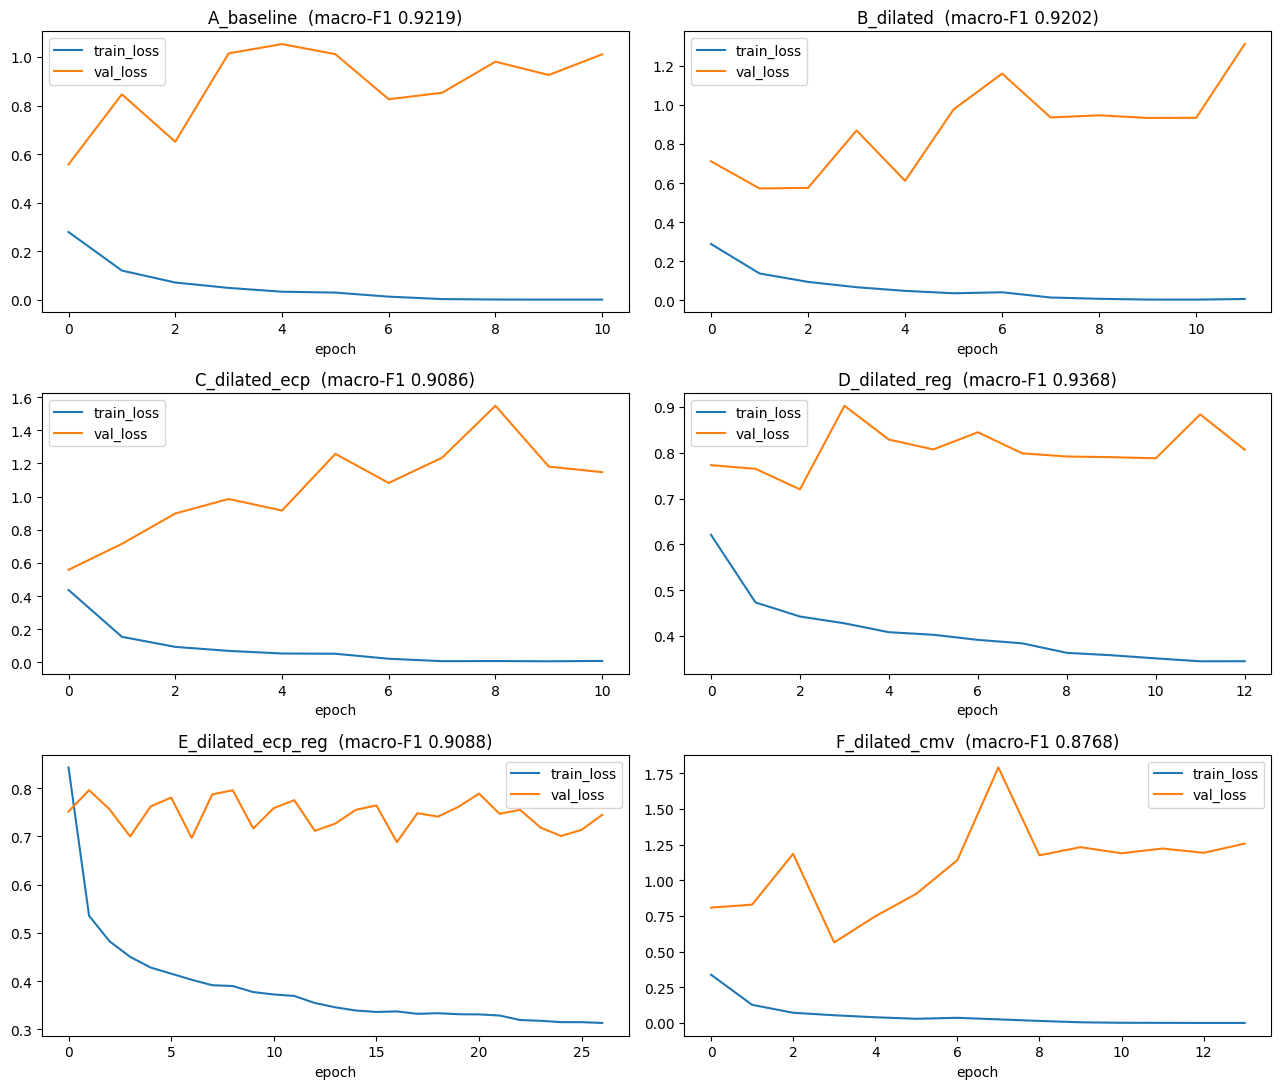

In [6]:
rows = []
for name, r in results.items():
    rows.append({
        'Variant': name,
        'Params': BUILDERS[name]().count_params(),
        'Macro-F1': r['macro_f1'],
        'Accuracy': r['acc'],
        'Epochs': r['n_epochs'],
        'Train-Val gap (last)': r['train_acc_final'] - r['val_acc_final'],
        **{f'F1_{a}': float(v) for a, v in zip(ACT_LABELS, r['per_class'])},
    })
ms_table = pd.DataFrame(rows).set_index('Variant')
print(ms_table.round(4).to_string())

os.makedirs('../results', exist_ok=True)
ms_table.to_csv('../results/arch_comparison_motionsense.csv')

# Plot learning curves on a 3x2 grid to see how train/val gap behaves.
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for ax, (name, r) in zip(axes.flat, results.items()):
    h = r['history'].history
    ax.plot(h['loss'], label='train_loss', color='tab:blue')
    ax.plot(h['val_loss'], label='val_loss', color='tab:orange')
    ax.set_title(f'{name}  (macro-F1 {r["macro_f1"]:.4f})')
    ax.set_xlabel('epoch'); ax.legend()
plt.tight_layout(); plt.show()


## Section 5 — In-the-wild robustness for each variant

Same Android pipeline as notebook 11 with the corrected load_session.

In [7]:
G = 9.80665
labels_df = pd.read_csv('../../data/in_the_wild/labels.csv').set_index('session_dir')


def load_session(session_dir):
    base = Path('../../data') / session_dir
    df_ori  = pd.read_csv(base/'Orientation.csv').sort_values('time')
    df_grav = pd.read_csv(base/'Gravity.csv').sort_values('time')
    df_gyr  = pd.read_csv(base/'Gyroscope.csv').sort_values('time')
    df_tot  = pd.read_csv(base/'TotalAcceleration.csv').sort_values('time')
    df = pd.merge_asof(df_ori[['time','roll','pitch','yaw']],
                       df_grav[['time','x','y','z']], on='time', suffixes=('','_grav'))
    df = pd.merge_asof(df, df_gyr[['time','x','y','z']], on='time', suffixes=('','_gyro'))
    df = pd.merge_asof(df, df_tot[['time','x','y','z']], on='time', suffixes=('','_tot_acc'))
    df.columns = ['time','attitude.roll','attitude.pitch','attitude.yaw',
                  'raw_gravity.x','raw_gravity.y','raw_gravity.z',
                  'rotationRate.x','rotationRate.y','rotationRate.z',
                  'raw_total_acc.x','raw_total_acc.y','raw_total_acc.z']
    df['time_dt'] = pd.to_datetime(df['time'])
    df = df.set_index('time_dt').resample('20ms').mean(numeric_only=True).interpolate(method='linear').reset_index(drop=True)
    df['raw_linear_acc.x'] = df['raw_total_acc.x'] - df['raw_gravity.x']
    df['raw_linear_acc.y'] = df['raw_total_acc.y'] - df['raw_gravity.y']
    df['raw_linear_acc.z'] = df['raw_total_acc.z'] - df['raw_gravity.z']
    df['gravity.x'] = -df['raw_gravity.x'] / G
    df['gravity.y'] = -df['raw_gravity.y'] / G
    df['gravity.z'] = -df['raw_gravity.z'] / G
    df['userAcceleration.x'] = -df['raw_linear_acc.x'] / G
    df['userAcceleration.y'] = -df['raw_linear_acc.y'] / G
    df['userAcceleration.z'] = -df['raw_linear_acc.z'] / G
    df['attitude.pitch'] = -df['attitude.pitch']
    df['attitude.yaw']   = -df['attitude.yaw']
    df['attitude.yaw']   = df['attitude.yaw'] - df['attitude.yaw'].iloc[0]
    cols = ['attitude.roll','attitude.pitch','attitude.yaw',
            'gravity.x','gravity.y','gravity.z',
            'rotationRate.x','rotationRate.y','rotationRate.z',
            'userAcceleration.x','userAcceleration.y','userAcceleration.z']
    return df[cols].iloc[150:-150].reset_index(drop=True)


def window_into_batches(arr, w=128, s=64):
    if len(arr) < w: return np.empty((0, w, arr.shape[1]))
    return np.stack([arr[st:st+w] for st in range(0, len(arr)-w+1, s)], axis=0)


# Pre-compute feature windows for every session (so each variant doesn't repeat the work).
sessions_data = {}
for session, row in labels_df.iterrows():
    df_raw = load_session(session)
    feats = compute_walking_frame_features_v2(df_raw, fs_hz=50.0, smooth_seconds=5.0,
                                              group_cols=None, keep_meta=False)
    W = window_into_batches(feats[WALKING_FRAME_V2_COLS].to_numpy())
    if len(W) == 0:
        continue
    Wn = (W - W.mean(axis=1, keepdims=True)) / (W.std(axis=1, keepdims=True) + 1e-8)
    sessions_data[session] = {
        'X': Wn.astype(np.float32),
        'gt': int(row['activity_id']),
        'orientation': row['pocket_orientation'],
        'true_label': row['activity'],
        'n_windows': len(Wn),
    }
print(f'pre-computed {len(sessions_data)} sessions')


pre-computed 12 sessions


In [8]:
itw_rows = []
for variant, r in results.items():
    model = r['model']
    correct_per_session = {}
    total_correct = 0; total_windows = 0; sessions_majority_correct = 0
    for session, d in sessions_data.items():
        probs = model.predict(d['X'], verbose=0)
        preds = probs.argmax(axis=1)
        n_corr = int((preds == d['gt']).sum())
        correct_per_session[session] = n_corr / d['n_windows']
        total_correct += n_corr
        total_windows += d['n_windows']
        majority = int(np.bincount(preds, minlength=6).argmax())
        if majority == d['gt']:
            sessions_majority_correct += 1
    win_acc = total_correct / total_windows
    sess_acc = sessions_majority_correct / len(sessions_data)
    itw_rows.append({
        'Variant': variant,
        'win_acc': win_acc, 'sess_acc': sess_acc,
        **{f'sess_{s}': correct_per_session[s] for s in sessions_data},
    })

itw_table = pd.DataFrame(itw_rows).set_index('Variant')
print(itw_table[['win_acc', 'sess_acc']].round(4).to_string())

itw_table.to_csv('../results/arch_comparison_in_the_wild.csv')


                   win_acc  sess_acc
Variant                             
A_baseline          0.7542    0.8333
B_dilated           0.7083    0.8333
C_dilated_ecp       0.7167    0.8333
D_dilated_reg       0.6750    0.8333
E_dilated_ecp_reg   0.7125    0.7500
F_dilated_cmv       0.7000    0.8333


## Section 6 — Decision

Decide the winner: it must (1) exceed the macro-F1 of variant A
(baseline) and (2) hold or improve in-the-wild window-acc relative to
variant A. Ties broken by parameter count (smaller wins for
on-device deployment).

In [9]:
decision_df = pd.DataFrame({
    'macro_f1':      ms_table['Macro-F1'],
    'f1_ups':        ms_table['F1_ups'],
    'gap':           ms_table['Train-Val gap (last)'],
    'params':        ms_table['Params'],
    'in_wild_win':   itw_table['win_acc'],
    'in_wild_sess':  itw_table['sess_acc'],
})
print(decision_df.round(4).to_string())

best_ms = decision_df['macro_f1'].idxmax()
best_iw = decision_df['in_wild_win'].idxmax()
print(f'\nBest by MotionSense macro-F1: {best_ms} ({decision_df.loc[best_ms, "macro_f1"]:.4f})')
print(f'Best by in-the-wild window-acc: {best_iw} ({decision_df.loc[best_iw, "in_wild_win"]:.4f})')


                   macro_f1  f1_ups     gap  params  in_wild_win  in_wild_sess
Variant                                                                       
A_baseline           0.9219  0.9515  0.1785  111558       0.7542        0.8333
B_dilated            0.9202  0.8935  0.1919  111558       0.7083        0.8333
C_dilated_ecp        0.9086  0.9356  0.1716  111558       0.7167        0.8333
D_dilated_reg        0.9368  0.9225  0.1696  111558       0.6750        0.8333
E_dilated_ecp_reg    0.9088  0.8659  0.1892  111558       0.7125        0.7500
F_dilated_cmv        0.8768  0.8055  0.1713  111558       0.7000        0.8333

Best by MotionSense macro-F1: D_dilated_reg (0.9368)
Best by in-the-wild window-acc: A_baseline (0.7542)


## Section 7 — 5-fold CV for the best variant

In [10]:
winner_name = best_ms
print(f'Running 5-fold CV for {winner_name} ...')

X_full, y_full, g_full = sliding_windows(features_df, WALKING_FRAME_V2_COLS)
y_full = y_full.astype(int); X_full_n = normalize_dyn(X_full)

gkf = GroupKFold(n_splits=5); fold_f1s = []
for fold, (tr, te) in enumerate(gkf.split(X_full_n, y_full, groups=g_full)):
    tf.keras.backend.clear_session(); tf.random.set_seed(SEED); np.random.seed(SEED)
    m = BUILDERS[winner_name]()
    label_smoothing = 0.05 if winner_name in USE_LABEL_SMOOTHING else 0.0
    if label_smoothing > 0:
        ytr_oh = tf.one_hot(y_full[tr], depth=6).numpy()
        loss = losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
        ytr = ytr_oh
    else:
        loss = losses.SparseCategoricalCrossentropy(); ytr = y_full[tr]
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss=loss, metrics=['accuracy'])
    cw_f = compute_class_weight('balanced', classes=np.arange(6), y=y_full[tr])
    m.fit(X_full_n[tr], ytr, epochs=25, batch_size=32,
          class_weight={int(i): float(w) for i, w in enumerate(cw_f)}, verbose=0)
    yfp = m.predict(X_full_n[te], verbose=0).argmax(axis=1)
    f1 = f1_score(y_full[te], yfp, average='macro'); fold_f1s.append(f1)
    print(f'fold {fold+1}  subj={sorted(np.unique(g_full[te]).astype(int).tolist())}  macro-F1={f1:.4f}')
fold_f1s = np.array(fold_f1s)
print(f'\n{winner_name} 5-fold CV macro-F1: {fold_f1s.mean():.4f} ± {fold_f1s.std():.4f}')


Running 5-fold CV for D_dilated_reg ...


fold 1  subj=[9, 13, 18, 22]  macro-F1=0.8428


fold 2  subj=[7, 8, 19, 20, 23]  macro-F1=0.9151


fold 3  subj=[5, 6, 11, 15, 21]  macro-F1=0.9381


fold 4  subj=[0, 4, 14, 16, 17]  macro-F1=0.9169


fold 5  subj=[1, 2, 3, 10, 12]  macro-F1=0.9702

D_dilated_reg 5-fold CV macro-F1: 0.9166 ± 0.0419


## Section 8 — Save winner

In [11]:
best_model = results[winner_name]['model']
os.makedirs('../../models', exist_ok=True)
out_path = f'../../models/cnn_arch_{winner_name}.keras'
best_model.save(out_path)
with open(out_path.replace('.keras', '.preproc.json'), 'w') as f:
    json.dump({
        'variant': winner_name,
        'channel_order': WALKING_FRAME_V2_COLS,
        'window_size': 128, 'step': 64, 'fs_hz': 50.0, 'smooth_seconds': 5.0,
        'feature_module': 'utils.orientation_invariant_features.compute_walking_frame_features_v2',
        'all_dynamic_zscore': True,
        'label_smoothing': 0.05 if winner_name in USE_LABEL_SMOOTHING else 0.0,
    }, f, indent=2)
print(f'saved {out_path}')

ms_table.to_csv('../results/arch_comparison_motionsense.csv')
itw_table.to_csv('../results/arch_comparison_in_the_wild.csv')


saved ../../models/cnn_arch_D_dilated_reg.keras


## Section 9 - Bridge to notebooks 13 / 13-hp-sweep-baseline

The automatic selection above picks `D_dilated_reg` because it has the
highest MotionSense macro-F1 (0.9368 vs A's 0.9219). However, that
single-criterion decision contradicts the multi-criterion rule stated
in Section 6 of this notebook:

- **Acceptance criterion (1)** - *macro-F1 > 0.9519* (SVC-RBF reference):
  *no variant* passes it. D comes closest at 0.9368.
- **Acceptance criterion (2)** - *F1_ups >= 0.92*: A passes (0.9515),
  D barely passes (0.9225). Two dilated variants fail outright.
- **Acceptance criterion (3)** - *train/val gap visibly smaller than
  baseline*: only marginal differences (D: 0.170 vs A: 0.179).
- **Acceptance criterion (4)** - *Android session-acc >= 0.85*: no
  variant passes; all sit at 0.8333 except E_dilated_ecp_reg (0.7500).
- **In-the-wild window-acc** (deployment proxy): A *beats* every
  dilated variant (A=0.7542, D=0.6750, others <=0.7167). D's
  MotionSense advantage costs ~8 pp on the Android sessions.

Because the two best candidates (A and D) win on *different* axes
and neither dominates the other, the architectural comparison is
**inconclusive** with the default hyperparameters used here.
Resolving it requires giving both architectures the same
hyperparameter tuning budget so the comparison reflects each
architecture's *tuned* potential rather than the arbitrary defaults
chosen in Section 2.

The next two notebooks run parallel sweeps with identical search
spaces (14 configurations each, same val-only selection protocol):

- `13-hp-sweep.ipynb` -> tunes `D_dilated_reg`,
- `13-hp-sweep-baseline.ipynb` -> tunes `A_baseline`.

The final model for the Flutter app is selected from the better of
the two tuned candidates, evaluated jointly on MotionSense (held-out
test + 5-fold subject-wise CV) and on the Android in-the-wild
sessions.